# 第44篇 | 正则化：Ridge / Lasso 防止过拟合

> 这是「数据分析从入门到精通」系列的第 44 篇。回归诊断做完了，这篇来解决一个关键问题——过拟合。特征太多、模型太复杂时，Ridge 和 Lasso 正则化就是解药。萧何"约法三章"，模型也需要"约束"才能稳健。

嗨，我是小荷～ 上篇学会了诊断回归问题，今天来学一个超实用的技术：**正则化**。当特征太多、模型太复杂时，怎么防止它"死记硬背"（过拟合）？

---

## 一、什么是过拟合？

想象一个学生：
- **欠拟合**：上课睡觉，考试啥都不会
- **正常拟合**：认真学习，举一反三
- **过拟合**：把课本例题答案全背下来，题目稍微变一下就不会了

过拟合的模型在训练数据上表现很好，但遇到新数据就"翻车"。

下面我们用一张图直观展示机器学习里最重要的三个概念：欠拟合、正常拟合、过拟合。


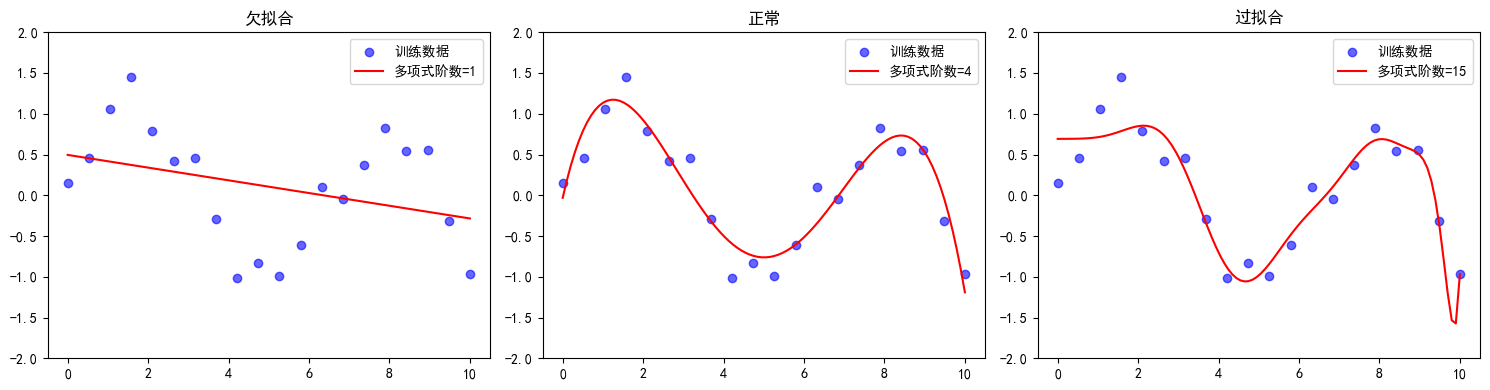

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 生成数据
np.random.seed(42)
X = np.linspace(0, 10, 20).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, 20)

# 不同复杂度的多项式回归
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, degree in enumerate([1, 4, 15]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    X_test = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred = model.predict(X_test)
    
    axes[i].scatter(X, y, color='blue', alpha=0.6, label='训练数据')
    axes[i].plot(X_test, y_pred, color='red', label=f'多项式阶数={degree}')
    axes[i].set_title(f'{"欠拟合" if degree==1 else "正常" if degree==4 else "过拟合"}')
    axes[i].legend()
    axes[i].set_ylim(-2, 2)

plt.rcParams['font.sans-serif'] = ['SimHei']   # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False
plt.tight_layout()
plt.show()


三张图到底是什么意思？（**超级关键**）

1. 阶数 = 1（一次函数，直线）
    - 模型太简单
    - 连数据基本趋势都抓不住
    - 欠拟合（Underfitting）

2. 阶数 = 4
    - 复杂度适中
    - 抓住了正弦趋势
    - 忽略了噪声
    - 正常拟合（最好）

3. 阶数 = 15
    - 模型太复杂
    - 拼命记住每一个噪声点
    - 曲线疯狂扭曲穿过每个点
    - 过拟合（Overfitting）
    - 泛化能力极差，换一组数据就崩

---

## 二、正则化的核心思想

正则化的核心思想就是：在保证模型 “准” 的前提下，让模型尽量 “简单、平滑”，从而防止过拟合。不要学得太细，不要太死记硬背，要学会通用规律。

打个比方：

模型学习 = 学生备考
  - 训练数据 = 练习题
  - 过拟合 = 死记硬背答案（题目稍微变一点就不会）
  - 正则化 = 不让你死记，强迫你理解规律
  - 简单模型 = 理解通用规律，能举一反三

正则化做的事：惩罚那些太复杂、太极端、太扭曲的解题方式，让模型保持简单。

**方法**：在损失函数中加入惩罚项，限制系数的大小：

$$
\text{总损失} = \text{MSE} + \lambda \times \text{惩罚项}
$$


核心思想就两点：
1. MSE 越小越好 → 让模型拟合数据
2. 惩罚项越小越好 → 让模型系数不要太大、曲线不要太抖

两种主流方法：

| 方法 | 惩罚项 | 特点 |
|------|--------|------|
| **Ridge (L2)** | $\sum \beta_j^2$ | 系数都变小，但不会变成0 |
| **Lasso (L1)** | $\sum |\beta_j|$ | 部分系数变成0，自动特征选择 |

---

## 三、Ridge 回归（L2正则化）

Ridge 回归（脊回归），在机器学习中更常被称为 L2 正则化。它是为了解决传统线性回归在面对复杂数据时最致命的两个死穴——过拟合（Overfitting）和多重共线性（Multicollinearity）而诞生的。

普通线性回归只追求：让预测值尽可能贴近真实值（最小化 MSE）；
Ridge 回归追求：既要拟合得准，又要模型简单、稳定。

如果把普通线性回归比作一个“激进、不放过任何数据死角”的学霸，那么 Ridge 回归就是一个“追求稳健、懂得适度放弃”的智者。

Ridge 回归（L2 正则化）通过惩罚过大的系数，让模型变得简单、平滑、稳定，从而解决过拟合与多重共线性，大幅提升模型泛化能力。




下面的代码通过少量样本 + 高阶多项式刻意制造严重过拟合，对比普通线性回归和带 L2 正则化的岭回归（Ridge）的效果，并用 MSE（均方误差） 和拟合曲线双重验证正则化的作用。


===== 训练集 MSE（图上看起来很好） =====
线性回归: 0.04
Ridge回归: 0.51

===== 测试集 MSE（真正实力！） =====
线性回归: 820.95
Ridge回归: 1.54


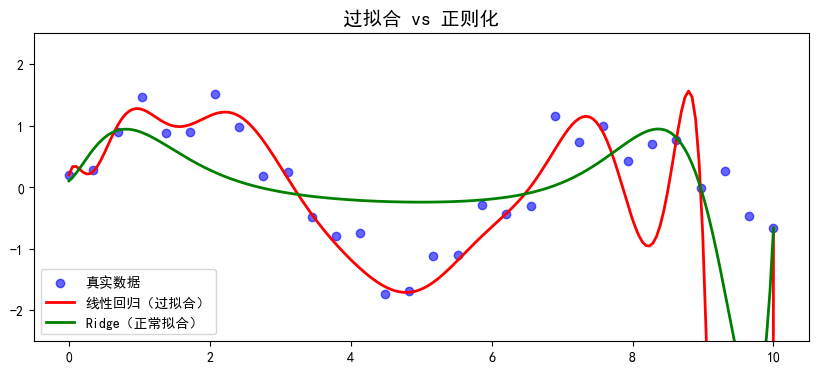

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 生成数据（30个样本，极易过拟合）
np.random.seed(42)
X = np.linspace(0, 10, 30).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.4, 30)

# 分成训练集、测试集（关键！才能看出过拟合）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 15阶多项式（必过拟合）
lr = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=15),
    LinearRegression()
)

ridge = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=15),
    Ridge(alpha=10)
)

# 训练
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# 训练集 MSE（你图上看到的“看起来很准”）
train_mse_lr = mean_squared_error(y_train, lr.predict(X_train))
train_mse_ridge = mean_squared_error(y_train, ridge.predict(X_train))

# 测试集 MSE（模型真正的预测能力）
test_mse_lr = mean_squared_error(y_test, lr.predict(X_test))
test_mse_ridge = mean_squared_error(y_test, ridge.predict(X_test))

# ====================== 输出结果（不报错版）======================
print("===== 训练集 MSE（图上看起来很好） =====")
print(f"线性回归: {train_mse_lr:.2f}")
print(f"Ridge回归: {train_mse_ridge:.2f}")

print("\n===== 测试集 MSE（真正实力！） =====")
print(f"线性回归: {test_mse_lr:.2f}")
print(f"Ridge回归: {test_mse_ridge:.2f}")

# ====================== 画图 ======================
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize=(10, 4))
plt.scatter(X, y, color='blue', alpha=0.6, label='真实数据')
plt.plot(X_plot, lr.predict(X_plot), 'r-', linewidth=2, label='线性回归（过拟合）')
plt.plot(X_plot, ridge.predict(X_plot), 'g-', linewidth=2, label='Ridge（正常拟合）')
plt.title('过拟合 vs 正则化', fontsize=14)
plt.legend()
plt.ylim(-2.5, 2.5)
plt.show()

**Ridge的特点**：
- 所有系数都向0收缩，但不会完全为0
- 适合处理**多重共线性**
- 保留了所有特征信息


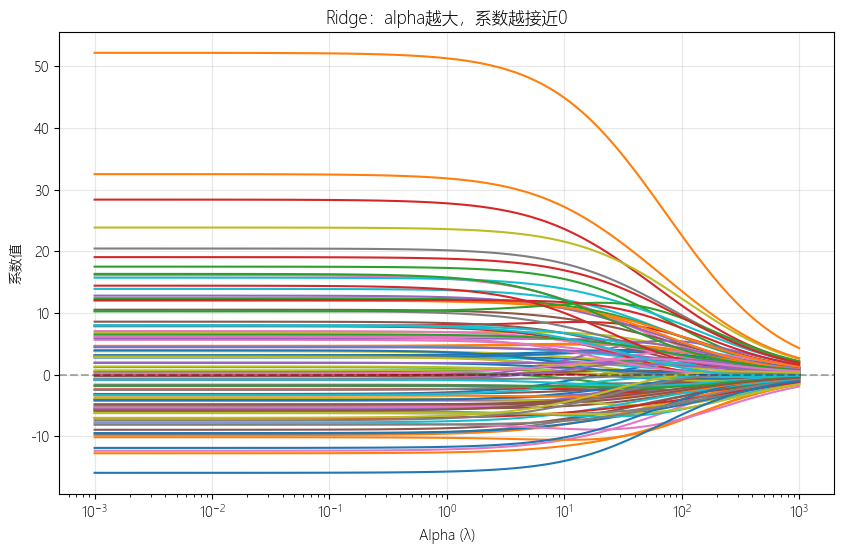

In [26]:
# 可视化不同alpha对系数的影响

from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=50,
    n_features=100,   # 总特征 100 个
    n_informative=10, # 真正有用的只有 10 个！
    noise=10,
    random_state=42
)

# 生成 100 个从 0.001 到 1000 的对数间距数值
# 测试从小到大的正则化强度
alphas = np.logspace(-3, 3, 100) 
coefs = [] # 存储每个 alpha 对应的系数

# 循环训练不同 alpha 的 Ridge，最后得到：100 组系数（对应 100 个 alpha）
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus'] = False
# plt.rcParams['mathtext.fontset'] = 'dejavusans' # 解决数学符号/负号找不到字形的问题

plt.figure(figsize=(10, 6))
# 一条线 = 一个特征的系数，横坐标：alpha，纵坐标：系数大小
plt.plot(alphas, coefs)
plt.xscale('log')  # 因为 alpha 从 0.001 → 1000，范围太大，必须用 log 才能看清楚。
plt.xlabel('Alpha (λ)')
plt.ylabel('系数值')
plt.title('Ridge：alpha越大，系数越接近0')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()


---

## 四、Lasso 回归（L1正则化）

Lasso 回归的全称是 Least Absolute Shrinkage and Selection Operator（最小绝对收缩和选择算子）。它的损失函数与 Ridge 非常相似，唯一的区别在于后面那个惩罚项（Penalty Term）：
$$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

Ridge (L2)： 惩罚的是系数的平方和（$\beta^2$）。Lasso (L1)： 惩罚的是系数的绝对值之和（$|\beta|$）。正是这个从“平方”到“绝对值”的微小数学转变，让 Lasso 拥有了 Ridge 梦寐以求、却永远无法拥有的超能力——自动特征选择（Feature Selection）。

它的终极杀招：制造“稀疏矩阵”与自动筛选特征在现实的商业场景中，我们经常会遇到“特征极度稀疏”的情况。比如预测癌症，我们测量了病人的 10,000 个基因特征（高维），但真正决定是否患病的可能只有 5 个基因。剩下的 9,995 个特征全是毫无意义的随机噪声。

- 如果用 Ridge (L2)： 它会把这 10,000 个特征的系数全部压得非常小（比如 0.0001），但没有任何一个会变成 0。最终你的预测方程里依然拖着 10,000 个特征的长尾巴，不仅模型极难解释，运行速度还慢。
- 如果用 Lasso (L1)： 它会精准地把那 5 个核心基因的系数保留下来，而把剩下 9,995 个没用特征的系数直接一刀切变成绝对的 0！

当系数变成 0 时，就意味着这个特征被彻底剔除出了模型。因此，Lasso 不仅能防止过拟合，还能顺手帮你把特征给筛了，生成一个干净、精简的稀疏模型（Sparse Model）。

In [27]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import make_regression

# ===================== 生成高维数据（特征超多，大部分没用）=====================
X, y = make_regression(
    n_samples=50,    # 样本少
    n_features=100,  # 100个特征（高维）
    n_informative=10,# 只有10个有用特征
    noise=10,
    random_state=42
)

# ===================== 训练两个模型 =====================
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

ridge.fit(X, y)
lasso.fit(X, y)

# ===================== 统计非零系数 =====================
ridge_non_zero = np.sum(ridge.coef_ != 0)
lasso_non_zero = np.sum(lasso.coef_ != 0)

total_features = len(ridge.coef_)

# ===================== 输出结果 =====================
print("===== 非零系数个数对比 =====")
print(f"Ridge (L2正则)  非零系数：{ridge_non_zero} / {total_features}")
print(f"Lasso (L1正则)  非零系数：{lasso_non_zero} / {total_features}")

===== 非零系数个数对比 =====
Ridge (L2正则)  非零系数：100 / 100
Lasso (L1正则)  非零系数：29 / 100


**Lasso的特点**：
- 产生**稀疏解**：很多系数变成0
- 自动完成**特征选择**
- 适合高维数据、需要解释性的场景


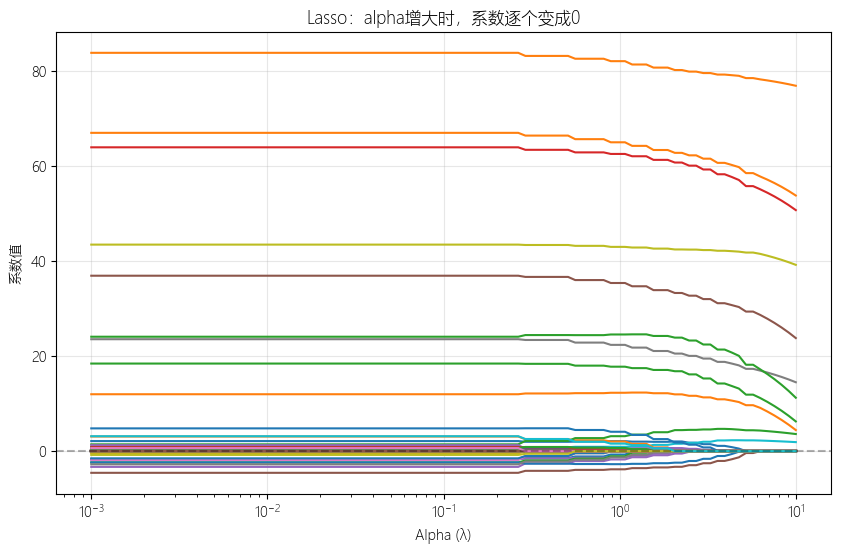

In [28]:
# 可视化Lasso的系数路径
from sklearn.linear_model import lasso_path

alphas_lasso, coefs_lasso, _ = lasso_path(X, y, alphas=np.logspace(-3, 1, 100))

plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i, :])

plt.xscale('log')
plt.xlabel('Alpha (λ)')
plt.ylabel('系数值')
plt.title('Lasso：alpha增大时，系数逐个变成0')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()

## 五、L到底是什么？

L 是一个非常核心的数学概念的简称，它代表的是 “勒贝格空间”（Lebesgue Space），通常也被俗称为 “长度（Length）” 或 “线性（Linear）” 空间。这个名字并不是机器学习发明的，而是直接从纯数学的泛函分析（Functional Analysis）中继承过来的。要彻底理解它，我们需要认识一位数学大师，并搞懂一个叫 $L_p$ 范数（Norm） 的工具。

1. 在数学界，为了纪念法国伟大的数学家 亨利·勒贝格（Henri Lebesgue），数学家们将一类特殊的函数空间命名为 勒贝格空间，并用他的名字首字母大写 $L$ 来表示。在这个空间里，有一种专门用来测量向量“长度”或“距离”的数学工具，叫做 $L_p$ 范数（$L_p$ Norm）。它的通用数学公式长这样：

$$\|x\|_p = \left( \sum_{i=1}^{n} |x_i|^p \right)^{\frac{1}{p}}$$

2. 为什么 Ridge 回归叫 L2？
   如果我们把公式中的 $p$ 换成 2，它就变成了 $L_2$ 范数：$$\|x\|_2 = \sqrt{x_1^2 + x_2^2 + \dots + x_n^2}$$这不就是我们初中就学过的勾股定理（欧几里得距离）吗？在二维空间里，一个点到原点的直角三角形斜边长度，就是这么算的。在机器学习中： 我们把模型的所有系数 $\beta$ 组合在一起，看成高维空间里的一个向量。Ridge 的惩罚项： 它的惩罚项是 $\sum \beta_j^2$。你会发现，这刚好就是 $L_2$ 范数的平方（也就是把外面那个根号给去掉了）。因此，因为 Ridge 回归的惩罚项完全基于 $L_2$ 范数的数学定义，它就被顺理成章地称为 L2 正则化。它惩罚的是系数向量在空间里的绝对几何距离（欧氏长度）。

3. 顺便认识一下 L1既然有 $L_2$，自然就有 $L_1$（也就是大名鼎鼎的 Lasso 回归）。如果我们把公式中的 $p$ 换成 1，就变成了 $L_1$ 范数：$$\|x\|_1 = |x_1| + |x_2| + \dots + |x_n|$$它不画斜线，而是把每个维度的绝对值直接相加。在现实生活中，这代表曼哈顿距离（就像在纽约曼哈顿街区开车，你不能穿过建筑走斜线，只能老老实实数自己过了几条街、几条大道）。

如果用一句话来总结 L 家族在机器学习里的门派：L1 正则化（Lasso）： 惩罚的是系数的绝对值之和。它下狠手时性格孤僻，喜欢把某些不重要的系数直接一刀切变成 0（适合做特征筛选）。L2 正则化（Ridge）： 惩罚的是系数的平方和。它是个完美主义者，由于有平方的存在，它拉扯大系数的力道极猛，但对小系数很温柔，会把所有系数一起压小，但绝不变成 0（适合稳健预测、抗共线性）。所以，L2 的 L 表面上指代的是勒贝格（Lebesgue）空间，但在我们脑海中，你完全可以把它粗暴但直观地记忆为 Length（长度）——它通过限制系数向量的“总长度”，来防止模型过度放飞自我！

---

## 六、如何选择 alpha？

正则化强度由 alpha 控制，太大太小都不行，得找到平衡点：


In [29]:
from sklearn.model_selection import GridSearchCV

# Ridge的alpha调优
ridge_params = {'alpha': np.logspace(-3, 3, 50)}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, 
                          scoring='neg_mean_squared_error')
ridge_grid.fit(X, y)

print(f"Ridge最优alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"最优CV得分: {-ridge_grid.best_score_:.2f}")

# Lasso的alpha调优
lasso_params = {'alpha': np.logspace(-3, 1, 50)}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5,
                          scoring='neg_mean_squared_error')
lasso_grid.fit(X, y)

print(f"\nLasso最优alpha: {lasso_grid.best_params_['alpha']:.4f}")
print(f"最优CV得分: {-lasso_grid.best_score_:.2f}")


Ridge最优alpha: 0.0010
最优CV得分: 13527.72

Lasso最优alpha: 0.7197
最优CV得分: 621.57


---

## 七、Elastic Net：Ridge + Lasso

终极折中——Elastic Net（弹性网络）： 小孩子才做选择，大人全都要！弹性网络把 L1 和 L2 惩罚项用一定的比例（l1_ratio）混合在了一起，既能像 Lasso 一样剔除垃圾特征，又能像 Ridge 一样稳定处理多重共线性，是目前工业界复杂线性建模中最常用的终极杀手锏。如果你纠结选哪个，可以用**Elastic Net**——两者的结合。


In [30]:
from sklearn.linear_model import ElasticNet

# Elastic Net有两个参数：alpha和l1_ratio
# l1_ratio=0 → 纯Ridge，l1_ratio=1 → 纯Lasso
elastic = ElasticNet(alpha=0.5, l1_ratio=0.5)
elastic.fit(X, y)

print(f"Elastic Net非零系数: {np.sum(elastic.coef_ != 0)}")


Elastic Net非零系数: 96


---

## 八、综合实战：房价预测的正则化

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来。

下面的代码用加州房价数据集（cal_housing.tgz，我已经下载到本地并上传到github），对比 4 种回归模型，看看谁预测房价最准、最简单、最不容易过拟合。
对比的 4 个模型：
- 普通线性回归（无正则化）
- Ridge（L2 正则化 → 压缩系数）
- Lasso（L1 正则化 → 自动删特征）
- ElasticNet（L1+L2 混合正则化）

输出指标：
- MSE：误差（越小越好）
- R²：准确率（越大越接近 1 越好）
- 非零系数：用了多少特征（越少越简单）

In [34]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression  # 全部导入

# 加载数据
data_dir = '../my_custom_data_folder'
housing = fetch_california_housing(data_home=data_dir)
X, y = housing.data, housing.target
feature_names = housing.feature_names

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化（正则化对特征尺度敏感！）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 对比四种模型
models = {
    '线性回归': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        '模型': name,
        'MSE': mean_squared_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
        '非零系数': np.sum(model.coef_ != 0) if hasattr(model, 'coef_') else '-'
    })
    
    print(f"\n{name}:")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"  R²: {r2_score(y_test, y_pred):.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*50)
print(results_df.to_string(index=False))




线性回归:
  MSE: 0.5559
  R²: 0.5758

Ridge:
  MSE: 0.5559
  R²: 0.5758

Lasso:
  MSE: 0.6796
  R²: 0.4814

ElasticNet:
  MSE: 0.6359
  R²: 0.5148

        模型      MSE       R²  非零系数
      线性回归 0.555892 0.575788     8
     Ridge 0.555855 0.575816     8
     Lasso 0.679629 0.481361     3
ElasticNet 0.635857 0.514765     4


从上面的对比可以看到Ridge 综合最强，误差最低，R² 最高。Lasso 模型最简单，自动删掉了5个无用特征。

我们再来画一下4 个模型系数对比图。

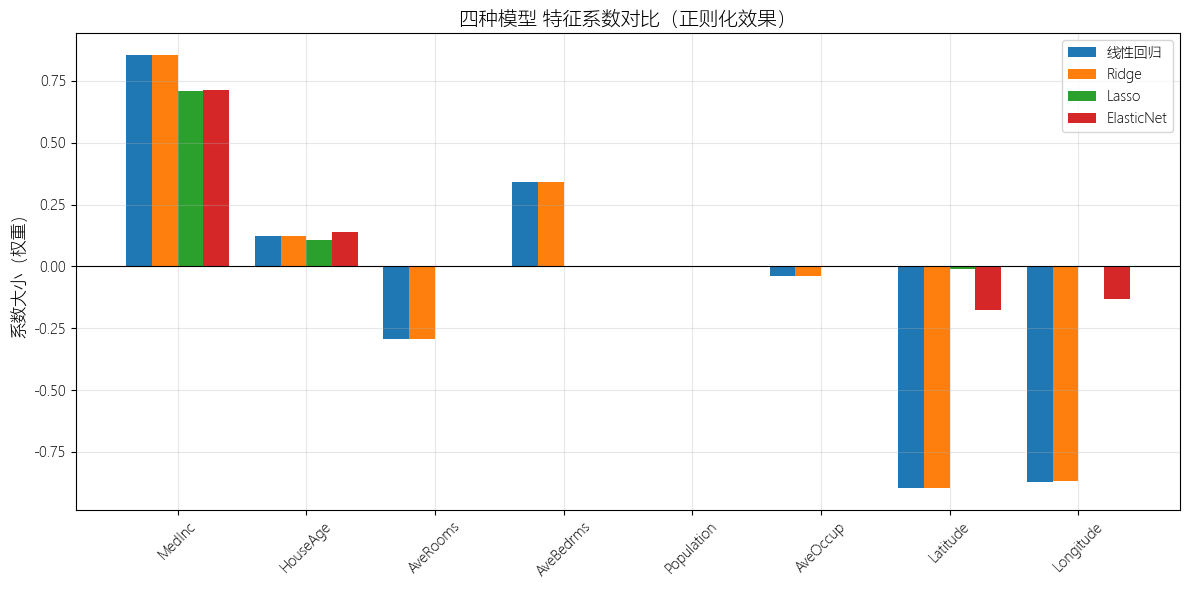

In [33]:
# ===================== 3. 画图：4 个模型系数对比 =====================
plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,6))

# 每个模型画一组柱状图
models_list = list(models.items())
n_features = len(feature_names)
x = np.arange(n_features)
width = 0.2  # 柱子宽度

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, (name, model) in enumerate(models_list):
    plt.bar(x + i*width, model.coef_, width=width, label=name, color=colors[i])

# 图表设置
plt.xticks(x + width*1.5, feature_names, rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('四种模型 特征系数对比（正则化效果）', fontsize=14)
plt.ylabel('系数大小（权重）', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 八、小结

| 方法 | 惩罚项 | 系数特点 | 适用场景 |
|------|--------|----------|----------|
| 普通线性回归 | 无 | 无约束 | 特征少、无共线性 |
| Ridge (L2) | $\sum \beta^2$ | 都变小，不为0 | 多重共线性、保留全部特征 |
| Lasso (L1) | $\sum \|\beta\|$ | 稀疏，部分为0 | 高维数据、特征选择 |
| Elastic Net | 混合 | 稀疏+收缩 | 特征数>样本数、相关特征多 |

**关键要点**：
1. 正则化前一定要**标准化**特征！
2. alpha通过**交叉验证**选择
3. Ridge适合保留信息，Lasso适合简化模型
4. 高维数据优先考虑Lasso或Elastic Net

---

## 九、课后练习

觉得这些任务不难，不搞代码了。

1. 用不同的alpha值训练Ridge，观察测试集MSE的变化曲线
2. 在Lasso中，找出被"淘汰"的特征，思考它们为什么不重要
3. 比较标准化前后的正则化效果差异

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 45 篇：逻辑回归 — 分类问题的回归解法**
>
> 下篇学逻辑回归——虽然名字里有「回归」，但它其实是做分类的！预测用户会不会购买、邮件是不是垃圾邮件。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*
